Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']

Accuracy: 0.9912280701754386

Confusion Matrix
[[42  1]
 [ 0 71]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



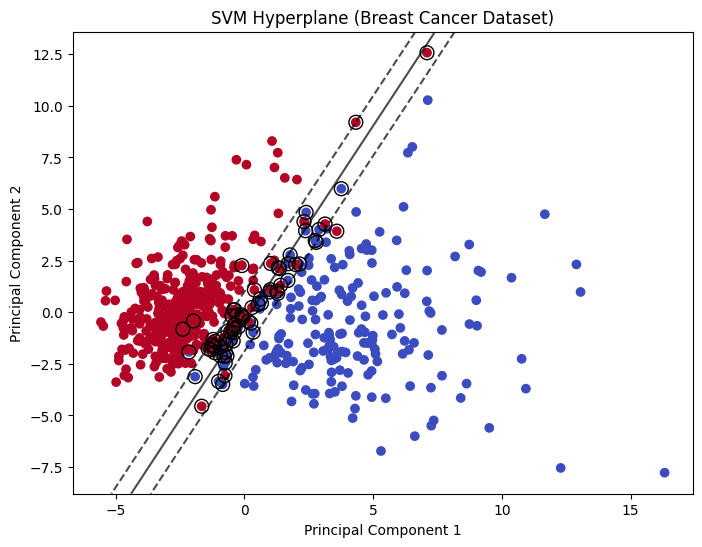

In [5]:
# ==========================================
# SVM with Hyperplane Visualization
# Breast Cancer Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)

# ------------------------------------------
# 2. Feature Scaling
# ------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------
# 3. PCA (Reduce to 2D for Visualization)
# ------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ------------------------------------------
# 4. Train Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# ------------------------------------------
# 5. Train SVM
# ------------------------------------------
model = SVC(kernel='linear')

model.fit(X_train, y_train)

# ------------------------------------------
# 6. Predictions
# ------------------------------------------
pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

# ------------------------------------------
# 7. Hyperplane Visualization
# ------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm')

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# create grid
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# plot hyperplane and margins
ax.contour(
    XX,
    YY,
    Z,
    colors='k',
    levels=[-1,0,1],
    alpha=0.7,
    linestyles=['--','-','--']
)

# highlight support vectors
ax.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=100,
    linewidth=1,
    facecolors='none',
    edgecolors='k'
)

plt.title("SVM Hyperplane (Breast Cancer Dataset)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()